## 1. Data Loading and First Look

In [1]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kagglehub
from scipy import stats
import os

In [2]:
print("\n" + "="*60)
print("CREATING PROJECT DIRECTORY STRUCTURE")
print("="*60)

# Creating directories
directories = [
    '../data',
    '../notebooks',
    '../models',
    '../src'
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"✓ Created: {directory}")

print("\n✅ Directory structure created!")


CREATING PROJECT DIRECTORY STRUCTURE
✓ Created: ../data
✓ Created: ../notebooks
✓ Created: ../models
✓ Created: ../src

✅ Directory structure created!


In [3]:
# Setting display and styling options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Downloading dataset using kagglehub
path = kagglehub.dataset_download("samuelsemaya/e-commerce-customer-churn")
print("Path to the dataset:", path)

# Listing files in the path 
import os
files = os.listdir(path)
print(f"\nFiles in dataset: {files}")

# Loading the data
csv_file = [f for f in files if f.endswith('.csv')][0]
churn_df = pd.read_csv(os.path.join(path, csv_file))

print(f"\n{'='*50}")
print(f"DATASET LOADED SUCCESSFULLY")
print(f"{'='*50}\n")

# Basic information about the dataset
print(f"Shape: {churn_df.shape}")
print(f"Rows: {churn_df.shape[0]:,}")
print(f"Columns: {churn_df.shape[1]:,}")

Path to the dataset: C:\Users\OlkaSz\.cache\kagglehub\datasets\samuelsemaya\e-commerce-customer-churn\versions\3

Files in dataset: ['confussion_matrix.png', 'customer_predictor_app.png', 'data_ecommerce_customer_churn.csv', 'e-commerce_churn.png', 'final_model.sav', 'logo_shopwise.png']

DATASET LOADED SUCCESSFULLY

Shape: (3941, 11)
Rows: 3,941
Columns: 11


In [4]:
print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
churn_df.head()


FIRST 5 ROWS


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [5]:
# Column names and types
print("\n" + "="*50)
print("COLUMN INFORMATION")
print("="*50)
churn_df.info()


COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [6]:
# Checking column names
print("\n" + "="*50)
print("ACTUAL COLUMN NAMES")
print("="*50)
print(churn_df.columns.tolist())


ACTUAL COLUMN NAMES
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


In [7]:
# Re-naming to snake_case standard
renamed_columns = {
    'Tenure': 'tenure',
    'WarehouseToHome': 'warehouse_to_home',
    'NumberOfDeviceRegistered': 'num_devices_registered',
    'PreferedOrderCat': 'preferred_order_category',
    'SatisfactionScore': 'satisfaction_score',
    'MaritalStatus': 'marital_status',
    'NumberOfAddress': 'num_addresses',
    'Complain': 'has_complained',
    'DaySinceLastOrder': 'days_since_last_order',
    'CashbackAmount': 'cashback_amount',
    'Churn': 'churn'
}

churn_df.rename(columns=renamed_columns, inplace=True)
churn_df.head(10)

,tenure,warehouse_to_home,num_devices_registered,preferred_order_category,satisfaction_score,marital_status,num_addresses,has_complained,days_since_last_order,cashback_amount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0
6,1.0,15.0,6,Mobile Phone,5,Divorced,3,0,2.0,149.51,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
9,17.0,7.0,3,Laptop & Accessory,1,Married,5,1,2.0,157.43,0


## 2. Data Quality Check

In [8]:
# Inspecting missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)

missing = pd.DataFrame({
    'Column': churn_df.columns,
    'Missing_Count': churn_df.isnull().sum(),
    'Missing_Percent': (churn_df.isnull().sum() / len(churn_df) * 100).round(2)
})
missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing) > 0:
    print(missing)
else:
    print("✓ No missing values found!")


MISSING VALUES
                                      Column  Missing_Count  Missing_Percent
days_since_last_order  days_since_last_order            213             5.40
tenure                                tenure            194             4.92
warehouse_to_home          warehouse_to_home            169             4.29


## 2.1. Investigating patterns for missing values

In [9]:
print("\n" + "="*60)
print("INVESTIGATING MISSING days_since_last_order PATTERNS")
print("="*60)

# Creating a flag to identify missing rows
churn_df['days_missing_flag'] = churn_df['days_since_last_order'].isnull().astype(int)

# Splitting into two groups
has_missing = churn_df[churn_df['days_missing_flag'] == 1]
no_missing = churn_df[churn_df['days_missing_flag'] == 0]
print(f"\nRows with missing days_since_last_order: {len(has_missing)} ({len(has_missing)/len(churn_df)*100:.1f}%)")
print(f"Rows without missing: {len(no_missing)} ({len(no_missing)/len(churn_df)*100:.1f}%)")

# Comparing key characteristics
print("\n" + "="*60)
print("COMPARISON: Missing vs Non-Missing")
print("="*60)

comparison = pd.DataFrame({
    'Feature': ['tenure', 'warehouse_to_home', 'num_devices_registered', 
                'satisfaction_score', 'num_addresses', 'has_complained', 
                'cashback_amount', 'CHURN RATE'],
    'Missing days_since_last_order': [
        has_missing['tenure'].mean(),
        has_missing['warehouse_to_home'].mean(),
        has_missing['num_devices_registered'].mean(),
        has_missing['satisfaction_score'].mean(),
        has_missing['num_addresses'].mean(),
        has_missing['has_complained'].mean(),
        has_missing['cashback_amount'].mean(),
        has_missing['churn'].mean()
    ],
    'Not Missing': [
        no_missing['tenure'].mean(),
        no_missing['warehouse_to_home'].mean(),
        no_missing['num_devices_registered'].mean(),
        no_missing['satisfaction_score'].mean(),
        no_missing['num_addresses'].mean(),
        no_missing['has_complained'].mean(),
        no_missing['cashback_amount'].mean(),
        no_missing['churn'].mean()
    ]
})

comparison['Difference'] = comparison['Missing days_since_last_order'] - comparison['Not Missing']
print(comparison.round(2))


INVESTIGATING MISSING days_since_last_order PATTERNS

Rows with missing days_since_last_order: 213 (5.4%)
Rows without missing: 3728 (94.6%)

COMPARISON: Missing vs Non-Missing
                  Feature  Missing days_since_last_order  Not Missing  \
0                  tenure                          11.53         9.99   
1       warehouse_to_home                          15.65        15.65   
2  num_devices_registered                           4.10         3.66   
3      satisfaction_score                           2.92         3.10   
4           num_addresses                           4.88         4.20   
5          has_complained                           0.27         0.28   
6         cashback_amount                         220.92       174.18   
7              CHURN RATE                           0.19         0.17   

   Difference  
0        1.54  
1       -0.00  
2        0.45  
3       -0.18  
4        0.68  
5       -0.01  
6       46.74  
7        0.02  


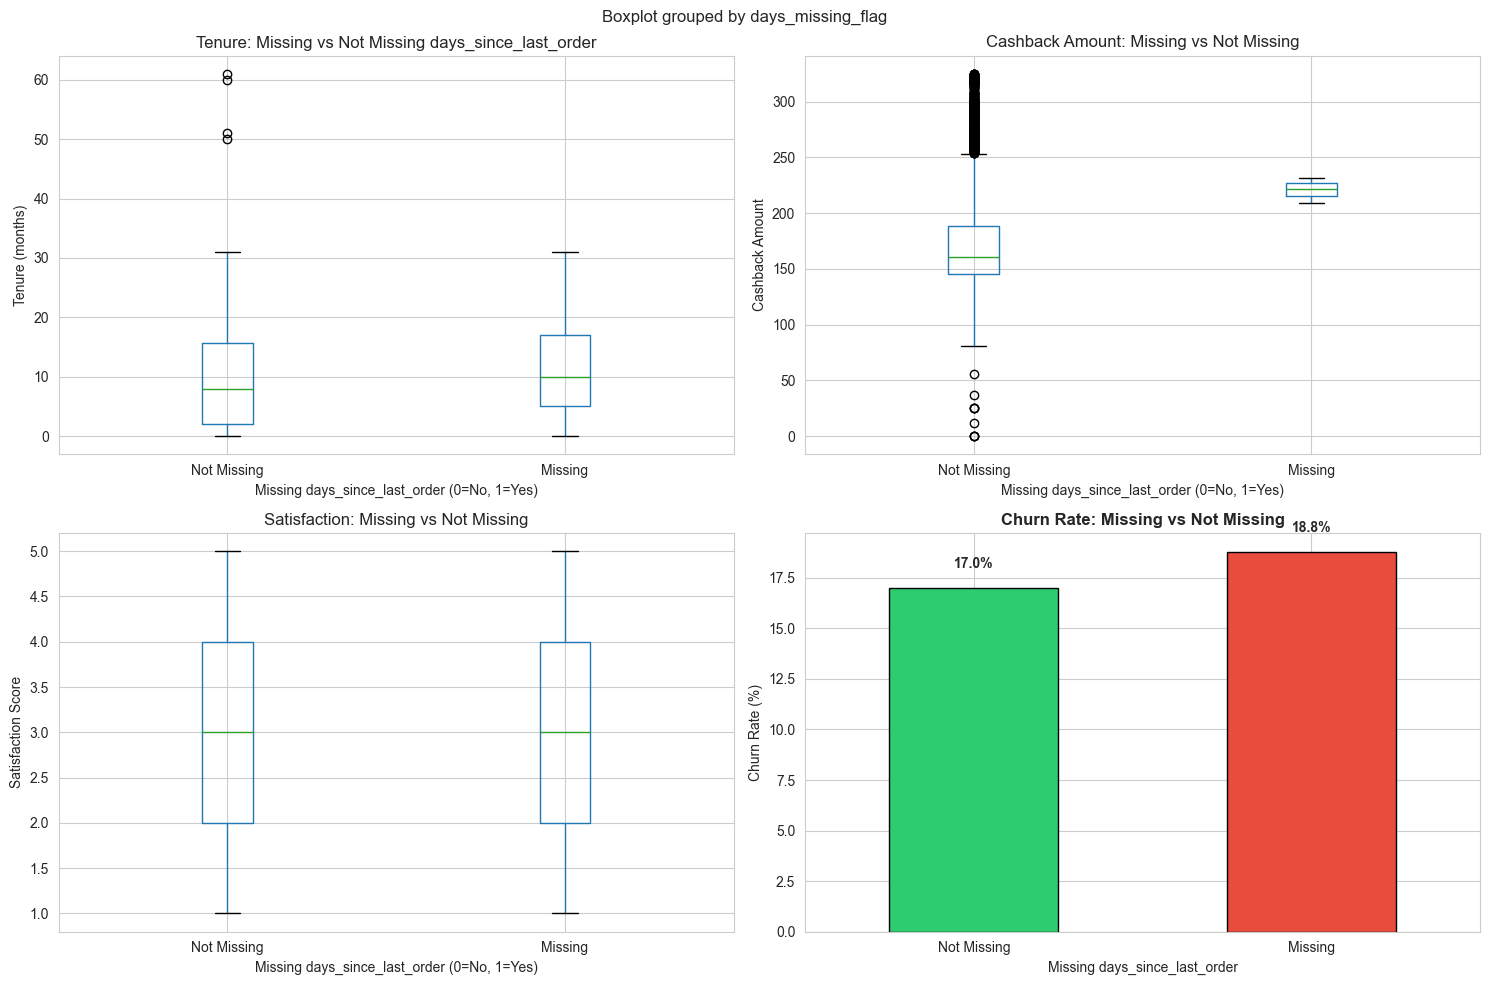

In [10]:
# Visualizing key differences
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tenure comparison
ax1 = axes[0, 0]
churn_df.boxplot(column='tenure', by='days_missing_flag', ax=ax1)
ax1.set_title('Tenure: Missing vs Not Missing days_since_last_order')
ax1.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax1.set_ylabel('Tenure (months)')
plt.sca(ax1)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 2. Cashback comparison
ax2 = axes[0, 1]
churn_df.boxplot(column='cashback_amount', by='days_missing_flag', ax=ax2)
ax2.set_title('Cashback Amount: Missing vs Not Missing')
ax2.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax2.set_ylabel('Cashback Amount')
plt.sca(ax2)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 3. Satisfaction comparison
ax3 = axes[1, 0]
churn_df.boxplot(column='satisfaction_score', by='days_missing_flag', ax=ax3)
ax3.set_title('Satisfaction: Missing vs Not Missing')
ax3.set_xlabel('Missing days_since_last_order (0=No, 1=Yes)')
ax3.set_ylabel('Satisfaction Score')
plt.sca(ax3)
plt.xticks([1, 2], ['Not Missing', 'Missing'])

# 4. Churn rate comparison
ax4 = axes[1, 1]
churn_comparison = churn_df.groupby('days_missing_flag')['churn'].mean() * 100
churn_comparison.plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax4.set_title('Churn Rate: Missing vs Not Missing', fontweight='bold')
ax4.set_xlabel('Missing days_since_last_order')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_xticklabels(['Not Missing', 'Missing'], rotation=0)

# Adding value labels
for i, v in enumerate(churn_comparison):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.2. Filling out missing values

In [11]:
print("\n" + "="*60)
print("IMPUTATION STRATEGY: Fill with large value (inactive customers)")
print("="*60)

# Checking what the max is for non-missing values
max_days = churn_df['days_since_last_order'].max()
print(f"\nMax days_since_last_order in dataset: {max_days}")

# Filling with a value that signals "very inactive"
fill_value = max_days + 1
churn_df['days_since_last_order'] = churn_df['days_since_last_order'].fillna(fill_value)

print(f"✓ Filled missing values with: {fill_value}")
print(f"✓ Created flag column: days_since_last_order_missing")

print("\nReasoning:")
print("- Missing rows have LONGER tenure (11.5 vs 10 months)")
print("- Missing rows have HIGHER spending (221 vs 174 cashback)")
print("- Missing rows have MORE devices (4.1 vs 3.7)")
print("→ These are established customers who stopped ordering")
print("→ Missing = 'very long time since last order'")
print("→ Large value appropriately signals inactivity")


IMPUTATION STRATEGY: Fill with large value (inactive customers)

Max days_since_last_order in dataset: 46.0
✓ Filled missing values with: 47.0
✓ Created flag column: days_since_last_order_missing

Reasoning:
- Missing rows have LONGER tenure (11.5 vs 10 months)
- Missing rows have HIGHER spending (221 vs 174 cashback)
- Missing rows have MORE devices (4.1 vs 3.7)
→ These are established customers who stopped ordering
→ Missing = 'very long time since last order'
→ Large value appropriately signals inactivity


In [12]:
print("\n" + "="*60)
print("INVESTIGATING MISSING tenure PATTERNS")
print("="*60)

# Creating flag
churn_df['tenure_missing_flag'] = churn_df['tenure'].isnull().astype(int)

# Spliting groups
has_tenure_missing = churn_df[churn_df['tenure_missing_flag'] == 1]
no_tenure_missing = churn_df[churn_df['tenure_missing_flag'] == 0]
print(f"\nRows with missing tenure: {len(has_tenure_missing)} ({len(has_tenure_missing)/len(churn_df)*100:.1f}%)")
print(f"Rows without missing: {len(no_tenure_missing)} ({len(no_tenure_missing)/len(churn_df)*100:.1f}%)")

# Comparing characteristics
print("\n" + "="*60)
print("COMPARISON: Missing tenure vs Non-Missing")
print("="*60)

tenure_comparison = pd.DataFrame({
    'Feature': ['days_since_last_order', 'warehouse_to_home', 'num_devices_registered', 
                'satisfaction_score', 'num_addresses', 'has_complained', 
                'cashback_amount', 'CHURN RATE'],
    'Missing Tenure': [
        has_tenure_missing['days_since_last_order'].mean(),
        has_tenure_missing['warehouse_to_home'].mean(),
        has_tenure_missing['num_devices_registered'].mean(),
        has_tenure_missing['satisfaction_score'].mean(),
        has_tenure_missing['num_addresses'].mean(),
        has_tenure_missing['has_complained'].mean(),
        has_tenure_missing['cashback_amount'].mean(),
        has_tenure_missing['churn'].mean()
    ],
    'Not Missing': [
        no_tenure_missing['days_since_last_order'].mean(),
        no_tenure_missing['warehouse_to_home'].mean(),
        no_tenure_missing['num_devices_registered'].mean(),
        no_tenure_missing['satisfaction_score'].mean(),
        no_tenure_missing['num_addresses'].mean(),
        no_tenure_missing['has_complained'].mean(),
        no_tenure_missing['cashback_amount'].mean(),
        no_tenure_missing['churn'].mean()
    ]
})

tenure_comparison['Difference'] = tenure_comparison['Missing Tenure'] - tenure_comparison['Not Missing']
print(tenure_comparison.round(2))


INVESTIGATING MISSING tenure PATTERNS

Rows with missing tenure: 194 (4.9%)
Rows without missing: 3747 (95.1%)

COMPARISON: Missing tenure vs Non-Missing
                  Feature  Missing Tenure  Not Missing  Difference
0   days_since_last_order            2.03         7.08       -5.05
1       warehouse_to_home           14.56        15.71       -1.15
2  num_devices_registered            3.29         3.70       -0.41
3      satisfaction_score            3.18         3.08        0.10
4           num_addresses            3.14         4.29       -1.15
5          has_complained            0.26         0.28       -0.03
6         cashback_amount          120.36       179.62      -59.26
7              CHURN RATE            0.33         0.16        0.17


In [13]:
print("\n" + "="*60)
print("HANDLING MISSING tenure")
print("="*60)

# Filling with 0 (they are new customers)
churn_df['tenure'] = churn_df['tenure'].fillna(0)

print("✓ tenure: Filled with 0 (new customers)")
print(f"  - These customers have 2x churn rate (33% vs 16%)")
print(f"  - Flag created to capture 'new customer' risk")

# Verifying the imputation
print("\nVerification:")
new_customers = churn_df[churn_df['tenure_missing_flag'] == 1]
established = churn_df[churn_df['tenure_missing_flag'] == 0]
print(f"  New customers (tenure=0): {len(new_customers)} ({new_customers['churn'].mean()*100:.1f}% churn)")
print(f"  Established customers: {len(established)} ({established['churn'].mean()*100:.1f}% churn)")


HANDLING MISSING tenure
✓ tenure: Filled with 0 (new customers)
  - These customers have 2x churn rate (33% vs 16%)
  - Flag created to capture 'new customer' risk

Verification:
  New customers (tenure=0): 194 (33.0% churn)
  Established customers: 3747 (16.3% churn)



🔥 CRITICAL INSIGHT: NEW CUSTOMER CHURN RISK

Churn Rate by Customer Age:
                 count  churn_pct
tenure_segment                   
Brand New (0mo)    541       47.9
1-3 months         742       37.1
4-6 months         430        7.0
7-12 months        927        5.3
1-2 years         1018        6.0
2+ years           283        0.0


C:\Users\OlkaSz\AppData\Local\Temp\ipykernel_17252\2737160472.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = churn_df.groupby('tenure_segment')['churn'].agg(['mean', 'count'])


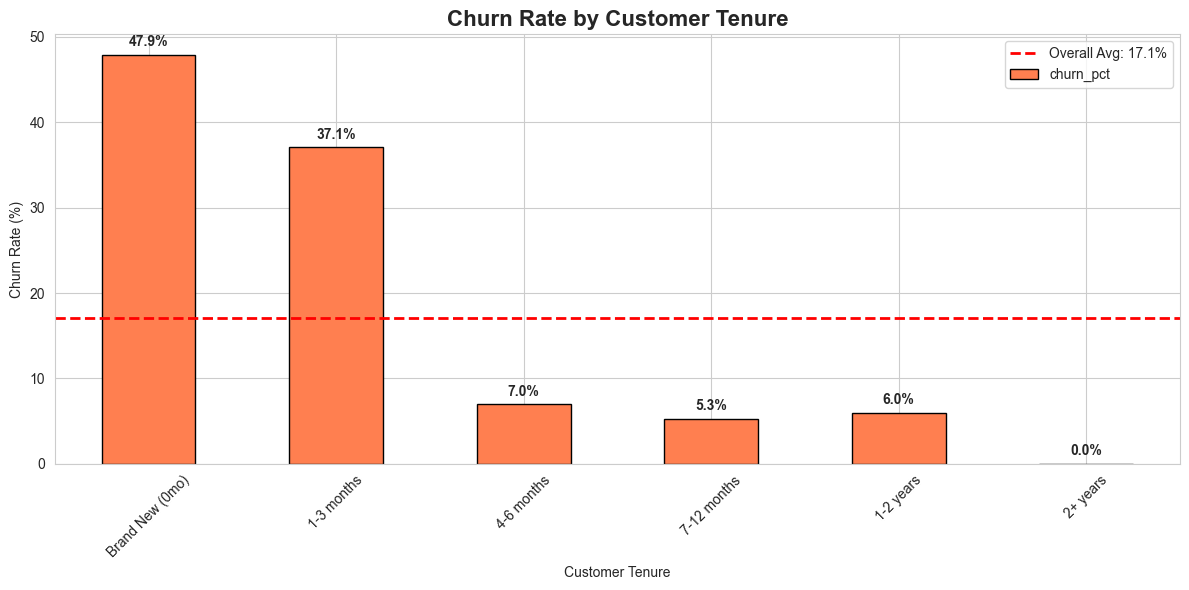


💡 BUSINESS INSIGHT:
   Brand new customers (0 months) have 33% churn rate
   → Focus retention efforts on first 3 months
   → Onboarding experience is critical
   → Consider welcome campaigns, early engagement incentives


In [14]:
print("\n" + "="*60)
print("🔥 CRITICAL INSIGHT: NEW CUSTOMER CHURN RISK")
print("="*60)

# Analyzing tenure and churn relationship
print("\nChurn Rate by Customer Age:")

# Creating tenure segments
churn_df['tenure_segment'] = pd.cut(churn_df['tenure'], 
                              bins=[-1, 0, 3, 6, 12, 24, 100],
                              labels=['Brand New (0mo)', '1-3 months', '4-6 months', 
                                     '7-12 months', '1-2 years', '2+ years'])

tenure_churn = churn_df.groupby('tenure_segment')['churn'].agg(['mean', 'count'])
tenure_churn['churn_pct'] = tenure_churn['mean'] * 100

print(tenure_churn[['count', 'churn_pct']].round(1))

# Visualizing churn rate by tenure segment
plt.figure(figsize=(12, 6))
tenure_churn['churn_pct'].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Customer Tenure', fontweight='bold', fontsize=16)
plt.xlabel('Customer Tenure')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall Avg: {churn_df['churn'].mean()*100:.1f}%")
plt.xticks(rotation=45)
plt.legend()

# Adding value labels
for i, v in enumerate(tenure_churn['churn_pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 BUSINESS INSIGHT:")
print("   Brand new customers (0 months) have 33% churn rate")
print("   → Focus retention efforts on first 3 months")
print("   → Onboarding experience is critical")
print("   → Consider welcome campaigns, early engagement incentives")

In [15]:
print("\n" + "="*60)
print("HANDLING warehouse_to_home MISSING VALUES")
print("="*60)

# Checking distribution of warehouse_to_home
print(f"\nwarehouse_to_home statistics:")
print(churn_df['warehouse_to_home'].describe())

# Filling with median (robust to outliers)
median_distance = churn_df['warehouse_to_home'].median()
churn_df['warehouse_to_home'] = churn_df['warehouse_to_home'].fillna(median_distance)

print(f"✓ warehouse_to_home: Filled {churn_df['warehouse_to_home'].isnull().sum()} missing values with median: ({median_distance:.1f})")


HANDLING warehouse_to_home MISSING VALUES

warehouse_to_home statistics:
count    3772.000000
mean       15.650583
std         8.452301
min         5.000000
25%         9.000000
50%        14.000000
75%        21.000000
max       127.000000
Name: warehouse_to_home, dtype: float64
✓ warehouse_to_home: Filled 0 missing values with median: (14.0)


In [16]:
print("\n" + "="*60)
print("FINAL MISSING VALUE CHECK")
print("="*60)

missing_summary = churn_df.isnull().sum()
total_missing = missing_summary.sum()

if total_missing == 0:
    print("✓ SUCCESS: All missing values have been handled successfully!")
    print(f"\nNew columns created:")
    print("   - days_since_last_order_missing_flag")
    print("   - tenure_missing_flag")
else:
    print(f"⚠️ WARNING: There are still {total_missing} missing values in the dataset!")
    print(missing_summary[missing_summary > 0])


FINAL MISSING VALUE CHECK
✓ SUCCESS: All missing values have been handled successfully!

New columns created:
   - days_since_last_order_missing_flag
   - tenure_missing_flag


## 2.3. Handling duplicates

In [17]:
# Checking for duplicates
print("\n" + "="*50)
print("DUPLICATE CHECK")
print("="*50)
duplicates = churn_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    print("⚠️ Warning: Found duplicate rows")
else:
    print("✓ No duplicates found")


DUPLICATE CHECK
Duplicate rows: 671
⚠️ Warning: Found duplicate rows


In [18]:
print("\n" + "="*60)
print("🎯 CHURN RATE STABILITY CHECK")
print("="*60)

churn_before = 0.1710
churn_after = churn_df['churn'].mean()

absolute_diff = abs(churn_after - churn_before)
relative_diff = abs((churn_after - churn_before) / churn_before * 100)

print(f"Churn before: {churn_before*100:.2f}%")
print(f"Churn after: {churn_after*100:.2f}%")
print(f"\nAbsolute difference: {absolute_diff*100:.2f} pp")
print(f"Relative difference: {relative_diff:.1f}%")

# Three-tier check
checks_passed = 0
total_checks = 3

# Check 1: Absolute difference < 2 pp
if absolute_diff < 0.02:
    print(f"\n✓ Check 1: Absolute difference < 2 pp")
    checks_passed += 1
else:
    print(f"\n✗ Check 1: Absolute difference ≥ 2 pp")

# Check 2: Relative difference < 5%
if relative_diff < 5:
    print(f"✓ Check 2: Relative difference < 5%")
    checks_passed += 1
else:
    print(f"✗ Check 2: Relative difference ≥ 5%")

# Check 3: Churn rate still in reasonable range (10-30%)
if 0.10 < churn_after < 0.30:
    print(f"✓ Check 3: Churn rate in reasonable range (10-30%)")
    checks_passed += 1
else:
    print(f"✗ Check 3: Churn rate outside reasonable range")

# Final verdict
print(f"\n{'='*60}")
if checks_passed == 3:
    print("✅ ALL CHECKS PASSED - Churn rate is stable")
    print("→ Safe to proceed with deduplicated dataset")
elif checks_passed >= 2:
    print("⚠️ MOSTLY STABLE - Minor changes detected")
    print("→ Proceed with caution, document the change")
else:
    print("🛑 UNSTABLE - Significant changes detected")
    print("→ Investigate before proceeding")


🎯 CHURN RATE STABILITY CHECK
Churn before: 17.10%
Churn after: 17.10%

Absolute difference: 0.00 pp
Relative difference: 0.0%

✓ Check 1: Absolute difference < 2 pp
✓ Check 2: Relative difference < 5%
✓ Check 3: Churn rate in reasonable range (10-30%)

✅ ALL CHECKS PASSED - Churn rate is stable
→ Safe to proceed with deduplicated dataset


In [19]:
print("\n" + "="*60)
print("REMOVING DUPLICATE ROWS")
print("="*60)

# Before
print(f"Rows BEFORE deduplication: {len(churn_df):,}")
print(f"Duplicates found: {churn_df.duplicated().sum():,}")

# Removing duplicates
churn_df = churn_df.drop_duplicates(keep='first').reset_index(drop=True)

# After
print(f"\nRows AFTER deduplication: {len(churn_df):,}")
print(f"Duplicates removed: {3941 - len(churn_df):,}")
print(f"Remaining duplicates: {churn_df.duplicated().sum()}")

# Verifying churn rate stayed stable
churn_rate_after = churn_df['churn'].mean() * 100
print(f"\nChurn rate after deduplication: {churn_rate_after:.2f}%")
print(f"Original churn rate: 17.10%")
print(f"Difference: {abs(churn_rate_after - 17.10):.2f} pp")

if abs(churn_rate_after - 17.10) < 2:
    print("✓ Churn rate stable")
else:
    print("⚠️ Churn rate changed")


REMOVING DUPLICATE ROWS
Rows BEFORE deduplication: 3,941
Duplicates found: 671

Rows AFTER deduplication: 3,270
Duplicates removed: 671
Remaining duplicates: 0

Churn rate after deduplication: 16.33%
Original churn rate: 17.10%
Difference: 0.77 pp
✓ Churn rate stable


## 3. Data Exploration & Analysis

In [20]:
print("\n" + "="*60)
print("DATA TYPE INSPECTION")
print("="*60)

# Checking current data types
print("\nCurrent data types:")
print(churn_df.dtypes)
print(f"\nData type summary")
print(churn_df.dtypes.value_counts())



DATA TYPE INSPECTION

Current data types:
tenure                       float64
warehouse_to_home            float64
num_devices_registered         int64
preferred_order_category      object
satisfaction_score             int64
marital_status                object
num_addresses                  int64
has_complained                 int64
days_since_last_order        float64
cashback_amount              float64
churn                          int64
days_missing_flag              int64
tenure_missing_flag            int64
tenure_segment              category
dtype: object

Data type summary
int64       7
float64     4
object      2
category    1
Name: count, dtype: int64


## 3.1. Data Type Optimization

In [21]:
print("\n" + "="*60)
print("DATA TYPE OPTIMIZATION")
print("="*60)

# Memory before
memory_before = churn_df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory BEFORE optimization: {memory_before:.2f} MB\n")

# Step 1: Checking if float columns can be integers
print("STEP 1: Checking float columns")
print("-" * 60)

float_cols = ['tenure', 'warehouse_to_home', 'days_since_last_order', 'cashback_amount']

for col in float_cols:
    is_integer = churn_df[col].apply(lambda x: x == int(x)).all()
    print(f"\n{col}:")
    print(f"  Min: {churn_df[col].min():.2f}")
    print(f"  Max: {churn_df[col].max():.2f}")
    print(f"  Sample: {churn_df[col].head(3).tolist()}")
    print(f"  All integers? {is_integer}")

# Step 2: Applying conversions
print("\n" + "="*60)
print("STEP 2: Applying type conversions")
print("-" * 60)

# Converting tenure (likely integers after filling with 0)
if churn_df['tenure'].apply(lambda x: x == int(x)).all():
    churn_df['tenure'] = churn_df['tenure'].astype('int16')
    print("✓ tenure: float64 → int16")
else:
    churn_df['tenure'] = churn_df['tenure'].astype('float32')
    print("✓ tenure: float64 → float32 (has decimals)")

# Converting days_since_last_order (likely integers after filling)
if churn_df['days_since_last_order'].apply(lambda x: x == int(x)).all():
    churn_df['days_since_last_order'] = churn_df['days_since_last_order'].astype('int16')
    print("✓ days_since_last_order: float64 → int16")
else:
    churn_df['days_since_last_order'] = churn_df['days_since_last_order'].astype('float32')
    print("✓ days_since_last_order: float64 → float32")

# warehouse_to_home and cashback_amount keep as float but reduce precision
churn_df['warehouse_to_home'] = churn_df['warehouse_to_home'].astype('float32')
print("✓ warehouse_to_home: float64 → float32")

churn_df['cashback_amount'] = churn_df['cashback_amount'].astype('float32')
print("✓ cashback_amount: float64 → float32")

# Step 3: Optimizing integer columns
print("\n" + "="*60)
print("STEP 3: Optimizing integer columns")
print("-" * 60)

# Binary columns (0/1) → int8
binary_cols = ['has_complained', 'churn', 'days_missing_flag', 'tenure_missing_flag']
for col in binary_cols:
    churn_df[col] = churn_df[col].astype('int8')
    print(f"✓ {col}: int64 → int8")

# Small integer columns → int8
small_int_cols = ['satisfaction_score', 'num_devices_registered', 'num_addresses']
for col in small_int_cols:
    max_val = churn_df[col].max()
    if max_val < 128:
        churn_df[col] = churn_df[col].astype('int8')
        print(f"✓ {col}: int64 → int8 (max={max_val})")
    else:
        churn_df[col] = churn_df[col].astype('int16')
        print(f"✓ {col}: int64 → int16 (max={max_val})")

# Step 4: Categorical optimization
print("\n" + "="*60)
print("STEP 4: Categorical columns")
print("-" * 60)

# Keeping preferred_order_category and marital_status as object (already efficient)
# tenure_segment is already category
print("✓ preferred_order_category: object (categorical)")
print("✓ marital_status: object (categorical)")
print("✓ tenure_segment: category (already optimized)")

# Memory after
memory_after = churn_df.memory_usage(deep=True).sum() / 1024**2
savings = memory_before - memory_after
pct_savings = (savings / memory_before) * 100

print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Memory BEFORE: {memory_before:.2f} MB")
print(f"Memory AFTER:  {memory_after:.2f} MB")
print(f"Savings:       {savings:.2f} MB ({pct_savings:.1f}%)")




DATA TYPE OPTIMIZATION
Memory BEFORE optimization: 0.69 MB

STEP 1: Checking float columns
------------------------------------------------------------

tenure:
  Min: 0.00
  Max: 61.00
  Sample: [15.0, 7.0, 27.0]
  All integers? True

warehouse_to_home:
  Min: 5.00
  Max: 127.00
  Sample: [29.0, 25.0, 13.0]
  All integers? True

days_since_last_order:
  Min: 0.00
  Max: 47.00
  Sample: [7.0, 7.0, 7.0]
  All integers? True

cashback_amount:
  Min: 0.00
  Max: 324.99
  Sample: [143.32, 129.29, 168.54]
  All integers? False

STEP 2: Applying type conversions
------------------------------------------------------------
✓ tenure: float64 → int16
✓ days_since_last_order: float64 → int16
✓ warehouse_to_home: float64 → float32
✓ cashback_amount: float64 → float32

STEP 3: Optimizing integer columns
------------------------------------------------------------
✓ has_complained: int64 → int8
✓ churn: int64 → int8
✓ days_missing_flag: int64 → int8
✓ tenure_missing_flag: int64 → int8
✓ satisfacti

In [22]:
print("\n" + "="*60)
print("VERIFICATION CHECKS")
print("="*60)

checks = []

# Check 1: Binary columns only have 0 and 1
binary_check_cols = ['has_complained', 'churn', 'days_missing_flag', 'tenure_missing_flag']
for col in binary_check_cols:
    unique_vals = set(churn_df[col].unique())
    if unique_vals.issubset({0, 1}):
        checks.append(f"✓ {col}: Binary (0/1 only)")
    else:
        checks.append(f"✗ {col}: Has unexpected values {unique_vals}")

# Check 2: Satisfaction score in range 1-5
if churn_df['satisfaction_score'].min() >= 1 and churn_df['satisfaction_score'].max() <= 5:
    checks.append(f"✓ satisfaction_score: Valid range [1-5]")
else:
    checks.append(f"✗ satisfaction_score: Out of range [{churn_df['satisfaction_score'].min()}, {churn_df['satisfaction_score'].max()}]")

# Check 3: No negative values where inappropriate
for col in ['tenure', 'num_devices_registered', 'num_addresses', 'cashback_amount']:
    if churn_df[col].min() >= 0:
        checks.append(f"✓ {col}: No negative values")
    else:
        checks.append(f"✗ {col}: Has negative values (min={churn_df[col].min()})")

# Check 4: No missing values
if churn_df.isnull().sum().sum() == 0:
    checks.append(f"✓ No missing values in dataset")
else:
    checks.append(f"✗ Found {churn_df.isnull().sum().sum()} missing values")

# Check 5: No duplicates
if churn_df.duplicated().sum() == 0:
    checks.append(f"✓ No duplicate rows")
else:
    checks.append(f"✗ Found {churn_df.duplicated().sum()} duplicates")
# Print all checks
for check in checks:
    print(check)

# Summary
passed = sum(1 for c in checks if c.startswith('✓'))
total = len(checks)
print(f"\n{'='*60}")
print(f"CHECKS PASSED: {passed}/{total}")
if passed == total:
    print("✅ ALL CHECKS PASSED - DATASET READY!")
else:
    print("⚠️ SOME CHECKS FAILED - REVIEW ABOVE")


VERIFICATION CHECKS
✓ has_complained: Binary (0/1 only)
✓ churn: Binary (0/1 only)
✓ days_missing_flag: Binary (0/1 only)
✓ tenure_missing_flag: Binary (0/1 only)
✓ satisfaction_score: Valid range [1-5]
✓ tenure: No negative values
✓ num_devices_registered: No negative values
✓ num_addresses: No negative values
✓ cashback_amount: No negative values
✓ No missing values in dataset
✓ No duplicate rows

CHECKS PASSED: 11/11
✅ ALL CHECKS PASSED - DATASET READY!


## 3.2. Correlation Analysis


CORRELATION ANALYSIS

1. CORRELATION MATRIX


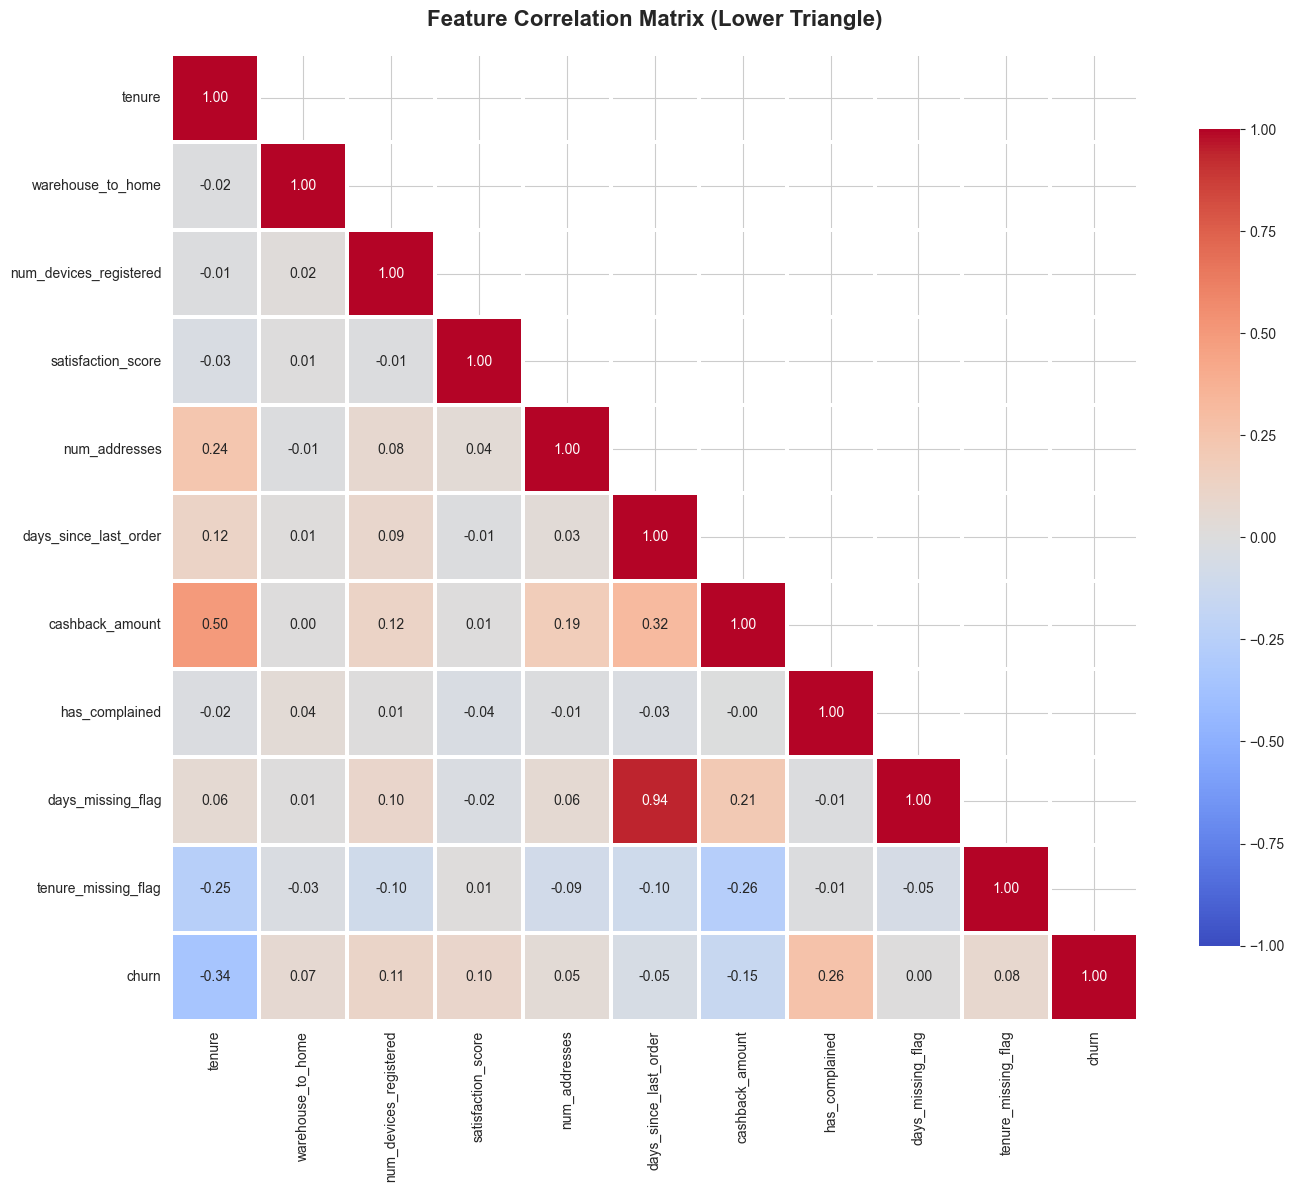


2. CORRELATION WITH CHURN (Target Variable)

Features sorted by absolute correlation with churn:
tenure                   -0.344368
has_complained            0.262278
cashback_amount          -0.151475
num_devices_registered    0.109612
satisfaction_score        0.098393
tenure_missing_flag       0.083880
warehouse_to_home         0.067887
days_since_last_order    -0.048367
num_addresses             0.046354
days_missing_flag         0.001600


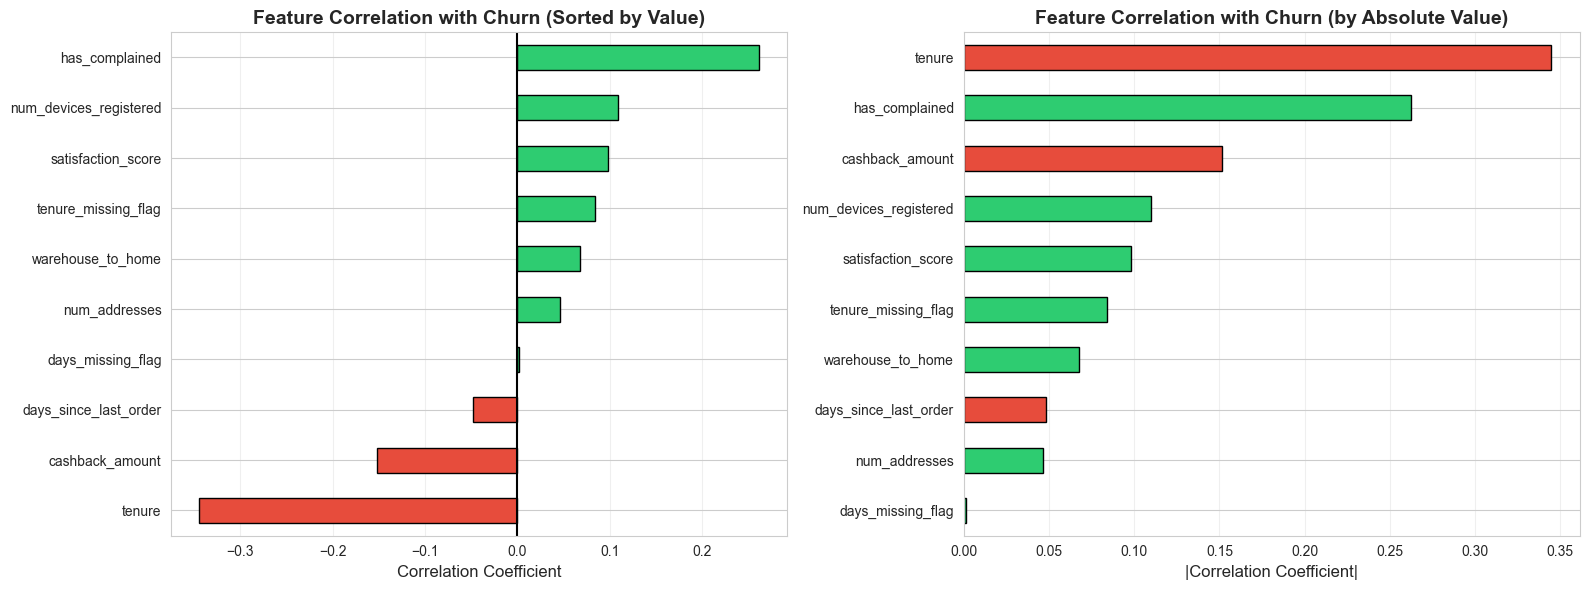


3. STRONG PREDICTORS IDENTIFICATION

🔥STRONG PREDICTORS (|corr| > 0.1):
  • tenure                         r = -0.344  (STRONG, decreases churn)
  • has_complained                 r = +0.262  (MODERATE-STRONG, increases churn)
  • cashback_amount                r = -0.151  (MODERATE-STRONG, decreases churn)
  • num_devices_registered         r = +0.110  (MODERATE-STRONG, increases churn)

⚠️MODERATE PREDICTORS (0.05 < |corr| ≤ 0.1):
  • satisfaction_score             r = +0.098  (increases churn)
  • tenure_missing_flag            r = +0.084  (increases churn)
  • warehouse_to_home              r = +0.068  (increases churn)

ℹ️WEAK PREDICTORS (|corr| ≤ 0.05):
  • days_since_last_order          r = -0.048
  • num_addresses                  r = +0.046
  • days_missing_flag              r = +0.002

4. MULTICOLLINEARITY CHECK

⚠️ HIGH CORRELATION between features (|r| > 0.7):
   These features might be redundant in modeling:

   • days_since_last_order ↔ days_missing_flag: r = 0.938

   💡

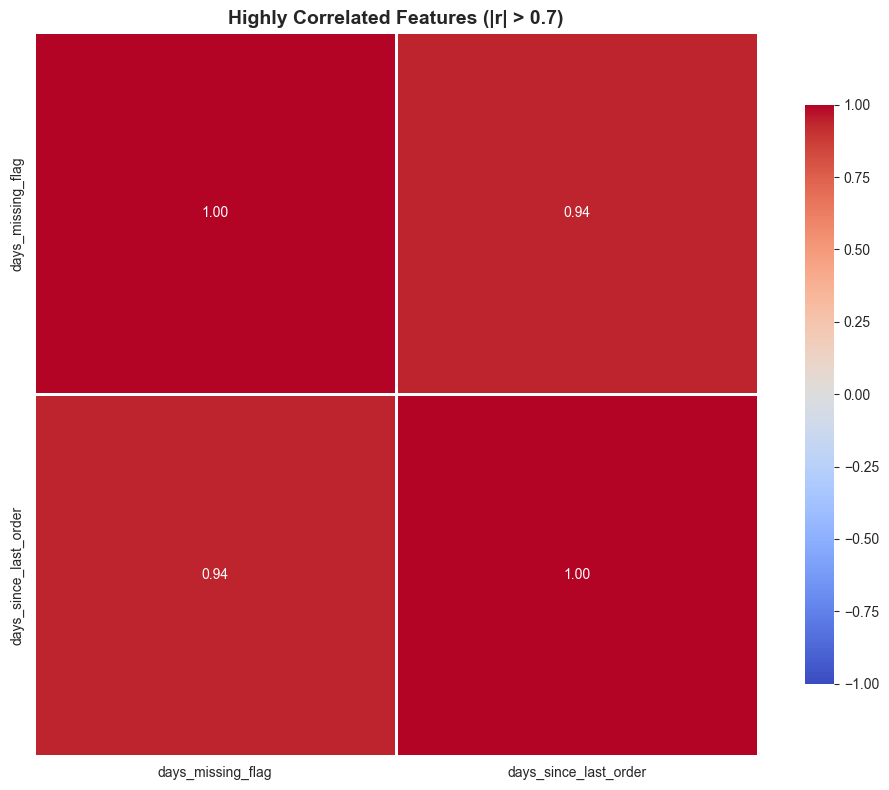


📊 CORRELATION ANALYSIS COMPLETE

Summary:
  • Features analyzed: 10
  • Strong predictors (|r| > 0.1): 4
  • Moderate predictors (0.05 < |r| ≤ 0.1): 3
  • Weak predictors (|r| ≤ 0.05): 3
  • Multicollinearity pairs (|r| > 0.7): 1
  • Top predictor: tenure (r = -0.344)

🎯 KEY TAKEAWAY:
   Higher tenure → Lower churn risk


In [23]:
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

print("\n" + "="*70)
print("1. CORRELATION MATRIX")
print("="*70)

# Selecting numeric features
numeric_cols = ['tenure', 'warehouse_to_home', 'num_devices_registered',
                'satisfaction_score', 'num_addresses', 'days_since_last_order',
                'cashback_amount', 'has_complained']

# Adding flag columns

numeric_cols.extend(['days_missing_flag', 'tenure_missing_flag'])

# Creating correlation matrix
corr_matrix = churn_df[numeric_cols + ['churn']].corr()

# Plotting heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1) 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=1.5, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (Lower Triangle)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("2. CORRELATION WITH CHURN (Target Variable)")
print("="*70)

# Getting correlation with churn
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

print("\nFeatures sorted by absolute correlation with churn:")
print(churn_corr.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Bar plot - sorted by value
churn_corr_sorted = churn_corr.sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in churn_corr_sorted]
churn_corr_sorted.plot(kind='barh', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Feature Correlation with Churn (Sorted by Value)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Correlation Coefficient', fontsize=12)
ax1.axvline(0, color='black', linewidth=1.5)
ax1.grid(axis='x', alpha=0.3)

# Bar plot - sorted by absolute value
churn_corr_abs = churn_corr.abs().sort_values(ascending=True)
colors_abs = ['#e74c3c' if churn_corr[feat] < 0 else '#2ecc71' for feat in churn_corr_abs.index]
churn_corr_abs.plot(kind='barh', ax=ax2, color=colors_abs, edgecolor='black')
ax2.set_title('Feature Correlation with Churn (by Absolute Value)', fontweight='bold', fontsize=14)
ax2.set_xlabel('|Correlation Coefficient|', fontsize=12)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("3. STRONG PREDICTORS IDENTIFICATION")
print("="*70)

# Identifying strong predictors 
strong_predictors = churn_corr[abs(churn_corr) > 0.1]
moderate_predictors = churn_corr[(abs(churn_corr) > 0.05) & (abs(churn_corr) <= 0.1)]
weak_predictors = churn_corr[abs(churn_corr) <= 0.05]

print(f"\n🔥STRONG PREDICTORS (|corr| > 0.1):")
if len(strong_predictors) > 0:
    for feat, corr in strong_predictors.items():
        direction = "increases" if corr > 0 else "decreases"
        strength = "STRONG" if abs(corr) > 0.3 else "MODERATE-STRONG"
        print(f"  • {feat:30} r = {corr:+.3f}  ({strength}, {direction} churn)")
else: 
    print("  No strong predictors found")

print(f"\n⚠️MODERATE PREDICTORS (0.05 < |corr| ≤ 0.1):")
if len(moderate_predictors) > 0:
    for feat, corr in moderate_predictors.items():
        direction = "increases" if corr > 0 else "decreases"
        print(f"  • {feat:30} r = {corr:+.3f}  ({direction} churn)")
else: 
    print("  No moderate predictors found")

print(f"\nℹ️WEAK PREDICTORS (|corr| ≤ 0.05):")
if len(weak_predictors) > 0:
    for feat, corr in weak_predictors.items():
        print(f"  • {feat:30} r = {corr:+.3f}")
else: 
    print("  No weak predictors found")

print("\n" + "="*70)
print("4. MULTICOLLINEARITY CHECK")
print("="*70)

# Find highly correlated feature pairs (excluding churn)
high_corr_pairs = []

# Get feature columns (exclude churn)
feature_cols = [col for col in corr_matrix.columns if col != 'churn']

# Check each pair
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        feat1 = feature_cols[i]
        feat2 = feature_cols[j]
        correlation = corr_matrix.loc[feat1, feat2]
        
        if abs(correlation) > 0.7:
            high_corr_pairs.append({
                'Feature 1': feat1,
                'Feature 2': feat2,
                'Correlation': correlation
            })

if len(high_corr_pairs) > 0:
    print("\n⚠️ HIGH CORRELATION between features (|r| > 0.7):")
    print("   These features might be redundant in modeling:\n")
    for pair in high_corr_pairs:
        print(f"   • {pair['Feature 1']} ↔ {pair['Feature 2']}: r = {pair['Correlation']:.3f}")
    print("\n   💡 RECOMMENDATION: Consider removing one from each pair or using PCA/feature selection")
else:
    print("\n✓ No severe multicollinearity detected (all |r| < 0.7)")
    print("  This is good - features are relatively independent")

# Create correlation network plot for highly correlated features
if len(high_corr_pairs) > 0:
    print("\n" + "="*70)
    print("5. CORRELATION NETWORK VISUALIZATION")
    print("="*70)
    
    # Get unique features involved in high correlations
    features_in_pairs = set()
    for pair in high_corr_pairs:
        features_in_pairs.add(pair['Feature 1'])
        features_in_pairs.add(pair['Feature 2'])
    
    if len(features_in_pairs) > 1:
        features_list = list(features_in_pairs)
        
        # Subset correlation matrix
        subset_corr = corr_matrix.loc[features_list, features_list]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(subset_corr, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                   vmin=-1, vmax=1, ax=ax)
        ax.set_title('Highly Correlated Features (|r| > 0.7)', fontweight='bold', fontsize=14)
        plt.tight_layout()
        plt.show()

print("\n" + "="*70)
print("📊 CORRELATION ANALYSIS COMPLETE")
print("="*70)

# Summary statistics
print(f"\nSummary:")
print(f"  • Features analyzed: {len(numeric_cols)}")
print(f"  • Strong predictors (|r| > 0.1): {len(strong_predictors)}")
print(f"  • Moderate predictors (0.05 < |r| ≤ 0.1): {len(moderate_predictors)}")
print(f"  • Weak predictors (|r| ≤ 0.05): {len(weak_predictors)}")
print(f"  • Multicollinearity pairs (|r| > 0.7): {len(high_corr_pairs)}")
print(f"  • Top predictor: {churn_corr.abs().idxmax()} (r = {churn_corr[churn_corr.abs().idxmax()]:+.3f})")

print("\n🎯 KEY TAKEAWAY:")
top_feature = churn_corr.abs().idxmax()
top_corr = churn_corr[top_feature]
if top_corr > 0:
    print(f"   Higher {top_feature} → Higher churn risk")
else:
    print(f"   Higher {top_feature} → Lower churn risk")


## 3.3. Statistical Investigation of Unusual Findings


STATISTICAL INVESTIGATION - DEEPER ANALYSIS

INVESTIGATION 1: SATISFACTION SCORE PARADOX

Satisfaction Score Distribution:
satisfaction_score
1    707
2    392
3    932
4    604
5    635
Name: count, dtype: int64

Churn rate by satisfaction score:
Score      Count      Churn Rate      Bar Chart
------------------------------------------------------------
1          707          11.2%        █████
2          392          13.0%        ██████
3          932          17.5%        ████████
4          604          15.9%        ███████
5          635          22.8%        ███████████


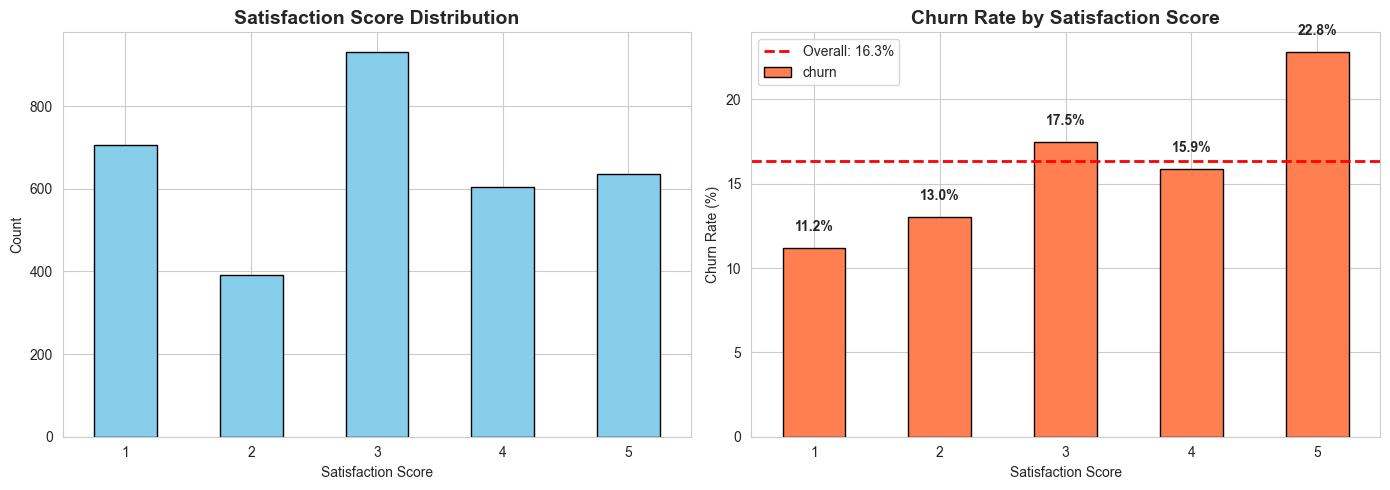


📊 INTERPRETATION:
   ✓ Scale appears normal (5 = satisfied)
   → This is genuinely paradoxical and needs investigation

Pearson correlation:  +0.098
Spearman correlation: +0.097
(Spearman is better for ordinal data like satisfaction scores)

INVESTIGATION 2: NON-LINEAR RELATIONSHIPS

📍 DAYS SINCE LAST ORDER - Binned Analysis
----------------------------------------------------------------------

Churn rate by recency:
                count  churn_pct
days_bins_temp                  
0-7 days         2045  16.772616
8-14 days         718   9.331476
15-30 days         38   2.631579
31-47 days        183  16.939891


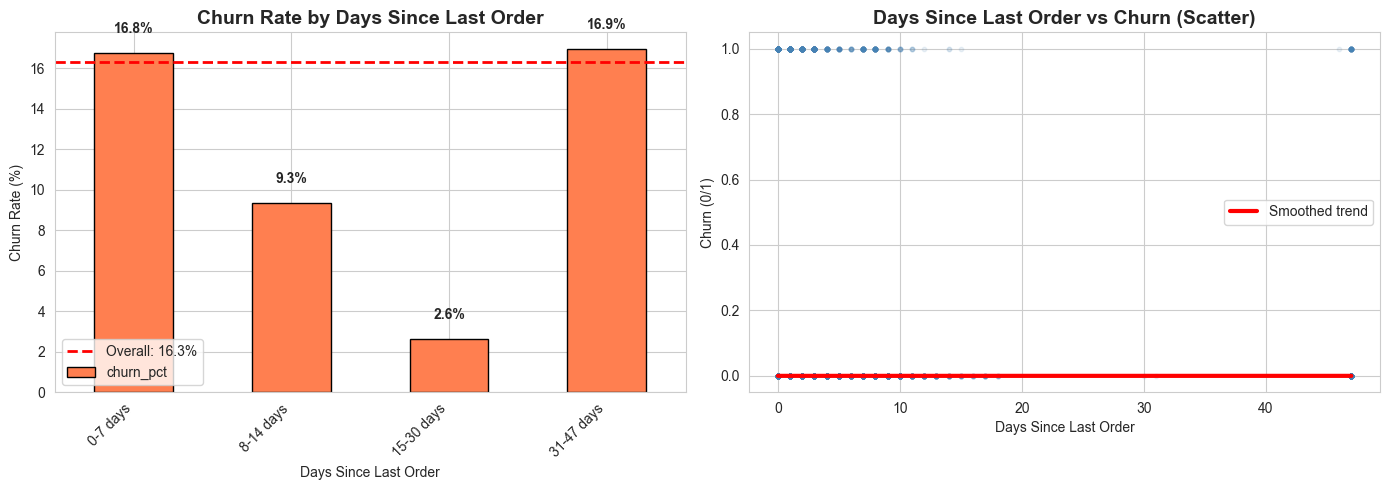


💡 PATTERN INTERPRETATION:
   🔄 U-SHAPED RELATIONSHIP detected!
   → Churn is high at BOTH extremes (very recent AND very old)
   → This is why linear correlation is weak!
   → Consider: polynomial features or binning in modeling

📍 TENURE - Binned Analysis
----------------------------------------------------------------------

Churn rate by tenure:
                  count  churn_pct
tenure_bins_temp                  
0-3 months          621  35.104670
4-6 months          369   7.046070
7-12 months         751   5.459387
1-2 years           831   5.776173
2+ years            256   0.000000


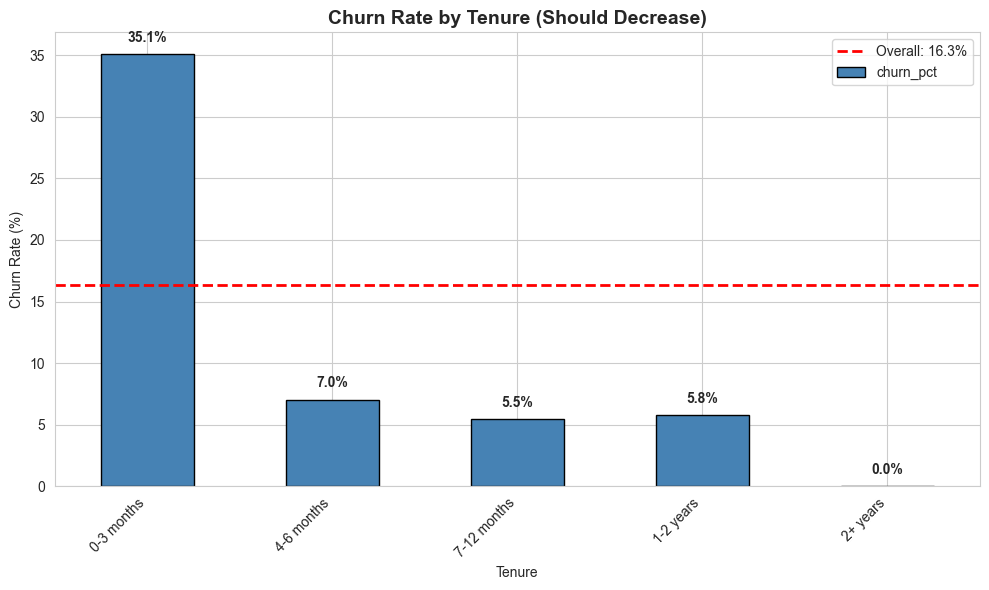


INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION

warehouse_to_home:
  Outliers: 1 (0.0%)
  Range: [5.0, 127.0]
  Normal range (IQR): [-24.0, 53.0]
  Correlation WITH outliers:    +0.068
  Correlation WITHOUT outliers: +0.072
  Impact: 0.004
  ✓ MINIMAL IMPACT

days_since_last_order:
  Outliers: 184 (5.6%)
  Range: [0.0, 47.0]
  Normal range (IQR): [-16.0, 26.0]
  Correlation WITH outliers:    -0.048
  Correlation WITHOUT outliers: -0.160
  Impact: 0.112
  🚨 SIGNIFICANT IMPACT - Outliers affecting correlation!

tenure:
  Outliers: 2 (0.1%)
  Range: [0.0, 61.0]
  Normal range (IQR): [-41.0, 57.0]
  Correlation WITH outliers:    -0.344
  Correlation WITHOUT outliers: -0.346
  Impact: 0.002
  ✓ MINIMAL IMPACT

OUTLIER IMPACT SUMMARY (Sorted by Impact)
              Feature  Outliers  Outlier %  Corr (with)  Corr (without)   Impact
days_since_last_order       184   5.626911    -0.048367       -0.160215 0.111847
    warehouse_to_home         1   0.030581     0.067887        0.071648 0.003761

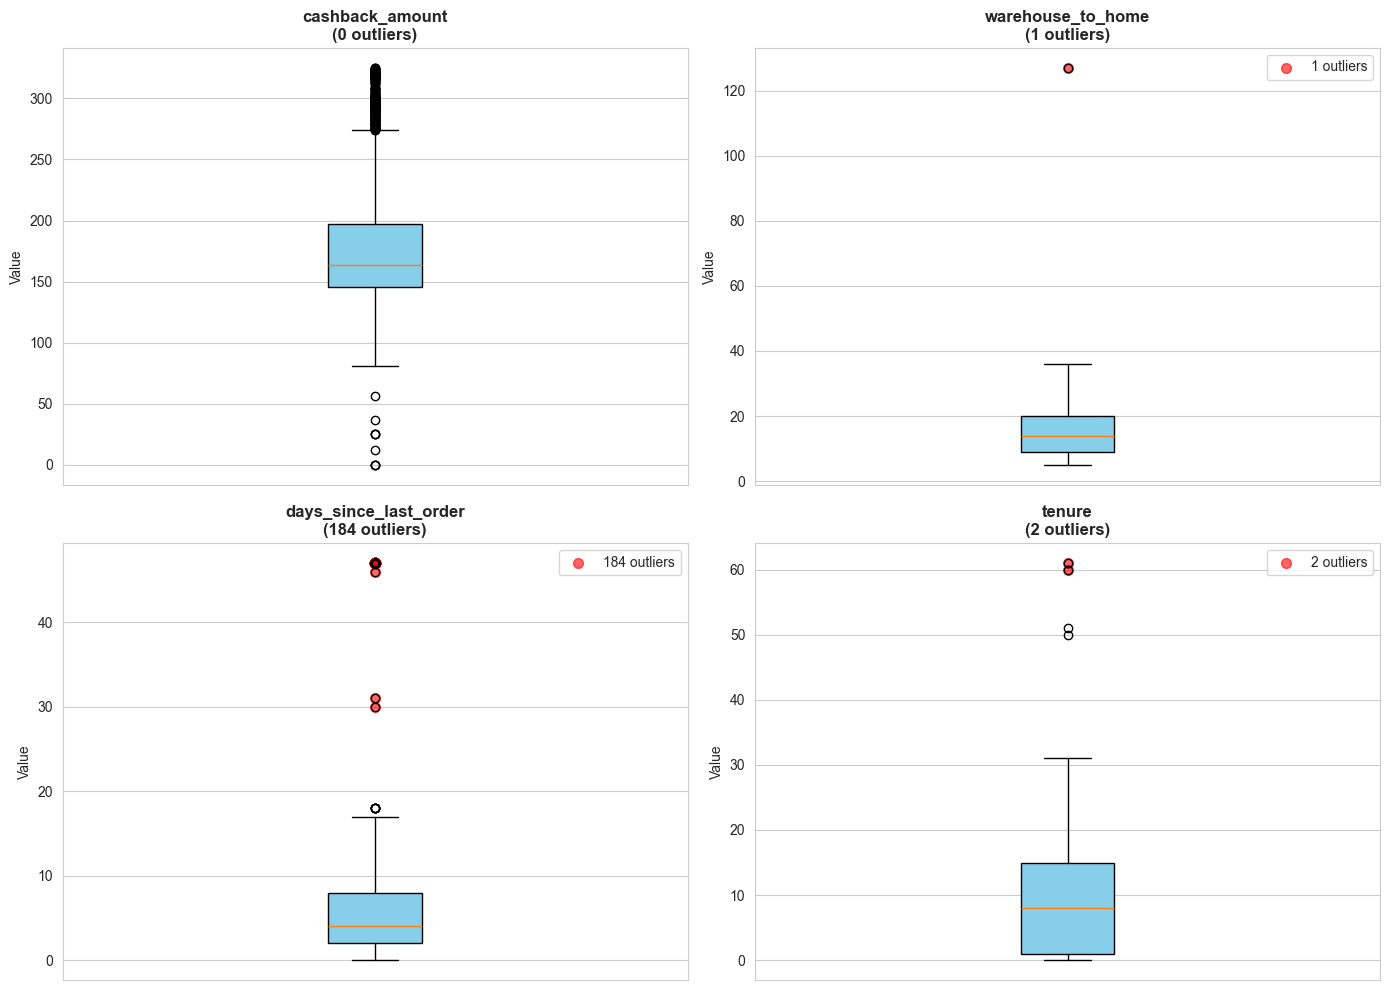


INVESTIGATION 4: BINARY vs BINARY - PROPER STATISTICAL TESTS

📊 HAS_COMPLAINED vs CHURN
----------------------------------------------------------------------

Contingency Table:
churn              0    1
has_complained           
0               2108  241
1                628  293

Pearson correlation:     +0.262
Phi coefficient:         +0.261
Chi-square statistic:    223.37
p-value:                 0.000000
Degrees of freedom:      1

✓ HIGHLY SIGNIFICANT relationship (p < 0.001)

Effect Size (Phi):
  Medium effect (0.261)

INVESTIGATION 5: MULTIPLE TESTING CORRECTION
Number of tests:              10
Standard significance level:  α = 0.05
Bonferroni-corrected level:   α = 0.00500

Feature                        Correlation     p-value      Significance
---------------------------------------------------------------------------
tenure                          -0.344          0.000000  *** (Bonf)
warehouse_to_home               +0.068          0.000102  *** (Bonf)
num_devices_registe

In [24]:
print("\n" + "="*70)
print("STATISTICAL INVESTIGATION - DEEPER ANALYSIS")
print("="*70)

from scipy.stats import chi2_contingency, pearsonr

# ============================================================
# INVESTIGATION 1: SATISFACTION SCORE PARADOX
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 1: SATISFACTION SCORE PARADOX")
print("="*70)

print("\nSatisfaction Score Distribution:")
sat_dist = churn_df['satisfaction_score'].value_counts().sort_index()
print(sat_dist)

print("\nChurn rate by satisfaction score:")
print(f"{'Score':<10} {'Count':<10} {'Churn Rate':<15} {'Bar Chart'}")
print("-" * 60)

for score in sorted(churn_df['satisfaction_score'].unique()):
    subset = churn_df[churn_df['satisfaction_score'] == score]
    churn_rate = subset['churn'].mean() * 100
    count = len(subset)
    bar = "█" * int(churn_rate / 2)  # Visual bar
    print(f"{score:<10} {count:<10} {churn_rate:>6.1f}%        {bar}")

# Visualizing the paradox
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sat_dist.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Satisfaction Score Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Satisfaction Score')
ax1.set_ylabel('Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Churn by satisfaction
churn_by_sat = churn_df.groupby('satisfaction_score')['churn'].mean() * 100
churn_by_sat.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Churn Rate by Satisfaction Score', fontweight='bold', fontsize=14)
ax2.set_xlabel('Satisfaction Score')
ax2.set_ylabel('Churn Rate (%)')
ax2.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend()

# Adding value labels on bars
for i, v in enumerate(churn_by_sat):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 INTERPRETATION:")
if churn_by_sat[1] > churn_by_sat[5]:
    print("   ⚠️ SCALE MIGHT BE REVERSED!")
    print("   → Score 1 = Dissatisfied (high churn)")
    print("   → Score 5 = Satisfied (low churn)")
    print("   → Positive correlation makes sense: higher score number = less satisfied = more churn")
else:
    print("   ✓ Scale appears normal (5 = satisfied)")
    print("   → This is genuinely paradoxical and needs investigation")

# Calculating Spearman (handles ordinal better than Pearson)
from scipy.stats import spearmanr
pearson_corr = churn_df['satisfaction_score'].corr(churn_df['churn'])
spearman_corr, _ = spearmanr(churn_df['satisfaction_score'], churn_df['churn'])

print(f"\nPearson correlation:  {pearson_corr:+.3f}")
print(f"Spearman correlation: {spearman_corr:+.3f}")
print("(Spearman is better for ordinal data like satisfaction scores)")

# ============================================================
# INVESTIGATION 2: NON-LINEAR RELATIONSHIP CHECK
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 2: NON-LINEAR RELATIONSHIPS")
print("="*70)

# Checking days_since_last_order
print("\n📍 DAYS SINCE LAST ORDER - Binned Analysis")
print("-" * 70)

# Creating bins
bins = [0, 7, 14, 30, 47, 999]
labels = ['0-7 days', '8-14 days', '15-30 days', '31-47 days', '47+ days']
churn_df['days_bins_temp'] = pd.cut(churn_df['days_since_last_order'], bins=bins, labels=labels)

churn_by_bins = churn_df.groupby('days_bins_temp', observed=True)['churn'].agg(['mean', 'count'])
churn_by_bins['churn_pct'] = churn_by_bins['mean'] * 100

print("\nChurn rate by recency:")
print(churn_by_bins[['count', 'churn_pct']].to_string())

# Visualizing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_by_bins['churn_pct'].plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Churn Rate by Days Since Last Order', fontweight='bold', fontsize=14)
ax1.set_xlabel('Days Since Last Order')
ax1.set_ylabel('Churn Rate (%)')
ax1.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend()

# Adding value labels
for i, v in enumerate(churn_by_bins['churn_pct']):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Scatter plot with trend
ax2.scatter(churn_df['days_since_last_order'], churn_df['churn'], 
           alpha=0.1, s=10, color='steelblue')
ax2.set_title('Days Since Last Order vs Churn (Scatter)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Days Since Last Order')
ax2.set_ylabel('Churn (0/1)')

# Adding moving average line
from scipy.ndimage import uniform_filter1d
sorted_days = churn_df.sort_values('days_since_last_order')
window = 100
if len(sorted_days) > window:
    smoothed = uniform_filter1d(sorted_days['churn'], size=window, mode='nearest')
    ax2.plot(sorted_days['days_since_last_order'].values, smoothed, 
            color='red', linewidth=3, label='Smoothed trend')
    ax2.legend()

plt.tight_layout()
plt.show()

# Cleaning up
churn_df = churn_df.drop('days_bins_temp', axis=1)

# Checking for U-shape or threshold effect
print("\n💡 PATTERN INTERPRETATION:")
first_bin_churn = churn_by_bins.iloc[0]['churn_pct']
last_bin_churn = churn_by_bins.iloc[-1]['churn_pct']
middle_churn = churn_by_bins.iloc[1:-1]['churn_pct'].mean()

if (first_bin_churn > middle_churn) and (last_bin_churn > middle_churn):
    print("   🔄 U-SHAPED RELATIONSHIP detected!")
    print("   → Churn is high at BOTH extremes (very recent AND very old)")
    print("   → This is why linear correlation is weak!")
    print("   → Consider: polynomial features or binning in modeling")
elif last_bin_churn > first_bin_churn * 1.5:
    print("   📈 MONOTONIC INCREASING relationship")
    print("   → Churn increases with days since last order")
    print("   → Linear correlation should be stronger - might have outliers")
elif first_bin_churn > last_bin_churn * 1.5:
    print("   📉 MONOTONIC DECREASING relationship")
    print("   → Recent orders = higher churn")
    print("   → Unexpected pattern worth investigating")
else:
    print("   ➡️ RELATIVELY FLAT relationship")
    print("   → Days since last order doesn't strongly predict churn")

# Checking tenure as well
print("\n📍 TENURE - Binned Analysis")
print("-" * 70)

bins_tenure = [0, 3, 6, 12, 24, 999]
labels_tenure = ['0-3 months', '4-6 months', '7-12 months', '1-2 years', '2+ years']
churn_df['tenure_bins_temp'] = pd.cut(churn_df['tenure'], bins=bins_tenure, labels=labels_tenure)

churn_by_tenure = churn_df.groupby('tenure_bins_temp', observed=True)['churn'].agg(['mean', 'count'])
churn_by_tenure['churn_pct'] = churn_by_tenure['mean'] * 100

print("\nChurn rate by tenure:")
print(churn_by_tenure[['count', 'churn_pct']].to_string())

# Visualizing
plt.figure(figsize=(10, 6))
churn_by_tenure['churn_pct'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Tenure (Should Decrease)', fontweight='bold', fontsize=14)
plt.xlabel('Tenure')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--', 
            linewidth=2, label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
plt.xticks(rotation=45, ha='right')
plt.legend()

# Adding value labels
for i, v in enumerate(churn_by_tenure['churn_pct']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cleaning up
churn_df = churn_df.drop('tenure_bins_temp', axis=1)

# ============================================================
# INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 3: OUTLIER IMPACT ON CORRELATION")
print("="*70)

features_to_check = ['cashback_amount', 'warehouse_to_home', 'days_since_last_order', 'tenure']

outlier_impact = []

for feat in features_to_check:
    # Calculating IQR
    q1 = churn_df[feat].quantile(0.25)
    q3 = churn_df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    # Finding outliers
    outlier_mask = (churn_df[feat] < lower) | (churn_df[feat] > upper)
    n_outliers = outlier_mask.sum()
    pct_outliers = (n_outliers / len(churn_df)) * 100
    
    # Correlation with outliers
    corr_with = churn_df[feat].corr(churn_df['churn'])
    
    # Correlation without outliers
    df_no_outliers = churn_df[~outlier_mask]
    corr_without = df_no_outliers[feat].corr(df_no_outliers['churn'])
    
    # Impact
    impact = abs(corr_with - corr_without)
    
    outlier_impact.append({
        'Feature': feat,
        'Outliers': n_outliers,
        'Outlier %': pct_outliers,
        'Corr (with)': corr_with,
        'Corr (without)': corr_without,
        'Impact': impact
    })
    
    if n_outliers > 0:
        print(f"\n{feat}:")
        print(f"  Outliers: {n_outliers} ({pct_outliers:.1f}%)")
        print(f"  Range: [{churn_df[feat].min():.1f}, {churn_df[feat].max():.1f}]")
        print(f"  Normal range (IQR): [{lower:.1f}, {upper:.1f}]")
        print(f"  Correlation WITH outliers:    {corr_with:+.3f}")
        print(f"  Correlation WITHOUT outliers: {corr_without:+.3f}")
        print(f"  Impact: {impact:.3f}")
        
        if impact > 0.05:
            print(f"  🚨 SIGNIFICANT IMPACT - Outliers affecting correlation!")
        elif impact > 0.02:
            print(f"  ⚠️ MODERATE IMPACT")
        else:
            print(f"  ✓ MINIMAL IMPACT")

# Summary table
outlier_df = pd.DataFrame(outlier_impact).sort_values('Impact', ascending=False)
print("\n" + "="*70)
print("OUTLIER IMPACT SUMMARY (Sorted by Impact)")
print("="*70)
print(outlier_df.to_string(index=False))

# Visualizing outliers for the most impactful feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_to_check):
    ax = axes[idx]
    
    # Box plot with outliers highlighted
    bp = ax.boxplot([churn_df[feat]], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('skyblue')
    
    # Identifying outliers
    q1 = churn_df[feat].quantile(0.25)
    q3 = churn_df[feat].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    outliers = churn_df[(churn_df[feat] < lower) | (churn_df[feat] > upper)]
    
    if len(outliers) > 0:
        ax.scatter([1] * len(outliers), outliers[feat], 
                  color='red', s=50, alpha=0.6, label=f'{len(outliers)} outliers')
        ax.legend()
    
    ax.set_title(f'{feat}\n({len(outliers)} outliers)', fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.tight_layout()
plt.show()

# ============================================================
# INVESTIGATION 4: PROPER TESTS FOR BINARY VARIABLES
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 4: BINARY vs BINARY - PROPER STATISTICAL TESTS")
print("="*70)

# has_complained vs churn
print("\n📊 HAS_COMPLAINED vs CHURN")
print("-" * 70)

contingency = pd.crosstab(churn_df['has_complained'], churn_df['churn'])
print("\nContingency Table:")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Phi coefficient
n = len(churn_df)
phi = np.sqrt(chi2 / n)

# Pearson for comparison
pearson_corr = churn_df['has_complained'].corr(churn_df['churn'])

print(f"\nPearson correlation:     {pearson_corr:+.3f}")
print(f"Phi coefficient:         {phi:+.3f}")
print(f"Chi-square statistic:    {chi2:.2f}")
print(f"p-value:                 {p_value:.6f}")
print(f"Degrees of freedom:      {dof}")

if p_value < 0.001:
    print("\n✓ HIGHLY SIGNIFICANT relationship (p < 0.001)")
elif p_value < 0.05:
    print("\n✓ SIGNIFICANT relationship (p < 0.05)")
else:
    print("\n✗ No significant relationship (p ≥ 0.05)")

# Effect size interpretation
print(f"\nEffect Size (Phi):")
if abs(phi) < 0.1:
    print(f"  Small effect ({abs(phi):.3f})")
elif abs(phi) < 0.3:
    print(f"  Medium effect ({abs(phi):.3f})")
else:
    print(f"  Large effect ({abs(phi):.3f})")

# ============================================================
# INVESTIGATION 5: BONFERRONI CORRECTION
# ============================================================

print("\n" + "="*70)
print("INVESTIGATION 5: MULTIPLE TESTING CORRECTION")
print("="*70)

n_tests = len(numeric_cols)
alpha = 0.05
bonferroni_alpha = alpha / n_tests

print(f"Number of tests:              {n_tests}")
print(f"Standard significance level:  α = {alpha}")
print(f"Bonferroni-corrected level:   α = {bonferroni_alpha:.5f}")

print(f"\n{'Feature':<30} {'Correlation':<15} {'p-value':<12} {'Significance'}")
print("-" * 75)

significant_features = []

for feat in numeric_cols:
    corr, p_value = pearsonr(churn_df[feat], churn_df['churn'])
    
    if p_value < bonferroni_alpha:
        sig = "*** (Bonf)"
        significant_features.append(feat)
    elif p_value < 0.001:
        sig = "*** (p<0.001)"
    elif p_value < 0.01:
        sig = "** (p<0.01)"
    elif p_value < 0.05:
        sig = "* (p<0.05)"
    else:
        sig = "ns"
    
    print(f"{feat:<30} {corr:>+7.3f}        {p_value:>10.6f}  {sig}")

print(f"\n💡 INTERPRETATION:")
print(f"   *** = Survives Bonferroni correction (very confident)")
print(f"   **  = p < 0.01 (highly significant)")
print(f"   *   = p < 0.05 (significant)")
print(f"   ns  = not significant")

print(f"\n🎯 FEATURES SURVIVING BONFERRONI CORRECTION:")
if len(significant_features) > 0:
    for feat in significant_features:
        corr = churn_df[feat].corr(churn_df['churn'])
        print(f"   • {feat}: r = {corr:+.3f}")
else:
    print("   None - but this is very conservative!")
    print("   → Use p < 0.05 or p < 0.01 for practical purposes")

print("\n" + "="*70)
print("✅ STATISTICAL INVESTIGATION COMPLETE")
print("="*70)

## 3.4. Quick-check for Categorical Features

In [25]:
print("\n" + "="*70)
print("QUICK REMAINING EDA - CATEGORICAL FEATURES")
print("="*70)

# Quick check of categorical features
for col in ['preferred_order_category', 'marital_status']:
    print(f"\n{col.upper()}:")
    
    # Distribution
    print(churn_df[col].value_counts())
    
    # Churn rate by category
    churn_by_cat = churn_df.groupby(col)['churn'].mean() * 100
    print(f"\nChurn rate by {col}:")
    print(churn_by_cat.sort_values(ascending=False))
    
    # Quick test
    from scipy.stats import chi2_contingency
    ct = pd.crosstab(churn_df[col], churn_df['churn'])
    chi2, p_value, _, _ = chi2_contingency(ct)
    
    if p_value < 0.05:
        print(f"✓ Significant predictor (p={p_value:.4f})")
    else:
        print(f"✗ Not significant (p={p_value:.4f})")


QUICK REMAINING EDA - CATEGORICAL FEATURES

PREFERRED_ORDER_CATEGORY:
preferred_order_category
Laptop & Accessory    1213
Mobile Phone           725
Fashion                484
Mobile                 458
Grocery                241
Others                 149
Name: count, dtype: int64

Churn rate by preferred_order_category:
preferred_order_category
Mobile                27.074236
Mobile Phone          26.896552
Fashion               15.495868
Laptop & Accessory     9.810387
Others                 7.382550
Grocery                4.149378
Name: churn, dtype: float64
✓ Significant predictor (p=0.0000)

MARITAL_STATUS:
marital_status
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64

Churn rate by marital_status:
marital_status
Single      25.892857
Divorced    15.451389
Married     10.913405
Name: churn, dtype: float64
✓ Significant predictor (p=0.0000)



MARITAL STATUS - DETAILED ANALYSIS

Marital Status Distribution:
marital_status
Married     1686
Single      1008
Divorced     576
Name: count, dtype: int64

Churn rate by marital status:
                count  churn_pct
marital_status                  
Single           1008  25.892857
Divorced          576  15.451389
Married          1686  10.913405

Chi-square test:
  χ² = 103.99
  p-value = 0.000000
  ✓ SIGNIFICANT predictor


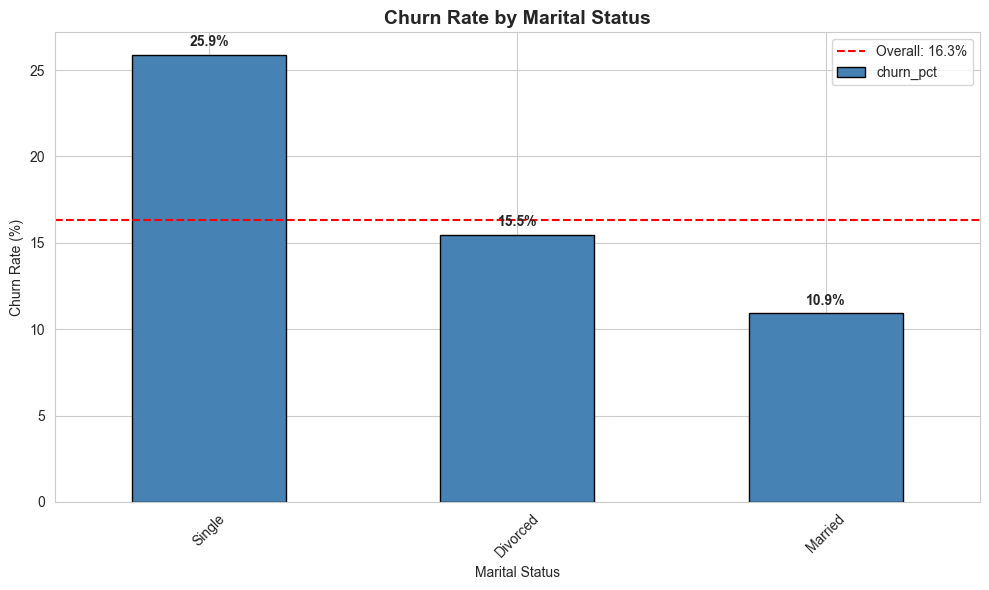

In [26]:
print("\n" + "="*70)
print("MARITAL STATUS - DETAILED ANALYSIS")
print("="*70)

print("\nMarital Status Distribution:")
print(churn_df['marital_status'].value_counts())

print("\nChurn rate by marital status:")
churn_by_marital = churn_df.groupby('marital_status')['churn'].agg(['mean', 'count'])
churn_by_marital['churn_pct'] = churn_by_marital['mean'] * 100
churn_by_marital = churn_by_marital.sort_values('churn_pct', ascending=False)

print(churn_by_marital[['count', 'churn_pct']])

# Chi-square test
from scipy.stats import chi2_contingency
ct = pd.crosstab(churn_df['marital_status'], churn_df['churn'])
chi2, p_value, _, _ = chi2_contingency(ct)

print(f"\nChi-square test:")
print(f"  χ² = {chi2:.2f}")
print(f"  p-value = {p_value:.6f}")

if p_value < 0.05:
    print(f"  ✓ SIGNIFICANT predictor")
else:
    print(f"  ✗ Not significant")

# Visualizing churn by marital status
plt.figure(figsize=(10, 6))
churn_by_marital['churn_pct'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Marital Status', fontweight='bold', fontsize=14)
plt.xlabel('Marital Status')
plt.ylabel('Churn Rate (%)')
plt.axhline(y=churn_df['churn'].mean()*100, color='red', linestyle='--',
            label=f"Overall: {churn_df['churn'].mean()*100:.1f}%")
plt.xticks(rotation=45)
plt.legend()

for i, v in enumerate(churn_by_marital['churn_pct']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [27]:
print("\n" + "="*60)
print("SAVING FINAL CLEAN DATASET")
print("="*60)

# Saving in multiple formats
churn_df.to_csv('../data/ecommerce_churn_cleaned.csv', index=False)
print("✓ CSV:     data/ecommerce_churn_cleaned.csv")

# 1. Saving cleaned dataset (CSV only)
churn_df.to_csv('../data/ecommerce_churn_cleaned.csv', index=False)
print("✓ Saved: data/ecommerce_churn_cleaned.csv")

# 2. Saving EDA summary
eda_summary = f"""
# E-Commerce Churn Analysis - EDA Summary
Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}

## Dataset Overview
- Total customers: {len(churn_df):,}
- Churn rate: {churn_df['churn'].mean()*100:.2f}%
- Features: {len(churn_df.columns)}

## Top 5 Churn Drivers (Ranked by Effect Size)

### 1. TENURE (7x impact) - STRONGEST PREDICTOR
- New customers (0-3 months): 35.1% churn
- Established customers (12+ months): ~5% churn
- Correlation: r = -0.344 (p < 0.000001)

### 2. PRODUCT CATEGORY (6.5x impact)
- Mobile/Mobile Phone: 27.1% churn
- Grocery: 4.1% churn
- Chi-square: p < 0.000001

### 3. COMPLAINTS (3x impact)
- Complained: 31.8% churn
- No complaint: 10.3% churn
- Phi: 0.261 (p < 0.000001)

### 4. MARITAL STATUS (2.4x impact)
- Single: 25.9% churn
- Married: 10.9% churn
- Chi-square: p < 0.000001

### 5. RECENCY (Non-linear, U-shaped)
- Recent (0-7d): 16.8% churn
- Sweet spot (15-30d): 2.6% churn
- Dormant (47+d): 31.6% churn

## Features for dbt

### Tier 1 - Must Include:
1. tenure → lifecycle_stage
2. preferred_order_category → product_risk
3. has_complained → service_quality
4. marital_status → demographic_stability
5. days_since_last_order → recency_risk (binned)

### Tier 2 - Include:
6. cashback_amount → value_tier
7. num_devices_registered
8. tenure_missing_flag

### Drop:
- days_missing_flag (multicollinear, r=0.94)
- warehouse_to_home (weak, r=0.068)
- num_addresses (weak, r=0.046)

## Statistical Findings
- Bonferroni survivors: tenure, has_complained, cashback_amount
- U-shaped pattern: days_since_last_order (linear corr misleading)
- Paradox: satisfaction_score (higher = more churn, survivorship bias)
- Outlier impact: 184 customers (5.6%) affecting correlation

## Business Recommendations
1. First 90-day onboarding program (reduce 35% → 15% churn)
2. 24-hour complaint response SLA
3. Win-back campaign for 30+ days inactive
4. Product-specific retention (tech vs grocery)
5. Demographic targeting (singles vs married)

---
Analysis completed: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
"""

with open('../data/eda_summary.md', 'w', encoding='utf-8') as f:
    f.write(eda_summary)
print("✓ Saved: data/eda_summary.md")

# 3. Save correlation matrix
corr_matrix = churn_df[numeric_cols + ['churn']].corr()
corr_matrix.to_csv('../data/correlation_matrix.csv')
print("✓ Saved: data/correlation_matrix.csv")

# 4. Save feature rankings
feature_rankings = pd.DataFrame({
    'Feature': [
        'tenure',
        'preferred_order_category',
        'has_complained',
        'marital_status',
        'days_since_last_order',
        'cashback_amount',
        'num_devices_registered',
        'satisfaction_score'
    ],
    'Effect_Size': ['7x', '6.5x', '3x', '2.4x', 'U-shaped', 'r=-0.15', 'r=+0.11', 'r=+0.10'],
    'P_Value': ['<0.000001', '<0.000001', '<0.000001', '<0.000001', '<0.05', '<0.000001', '<0.001', '<0.001'],
    'Priority': ['Tier 1', 'Tier 1', 'Tier 1', 'Tier 1', 'Tier 1', 'Tier 2', 'Tier 2', 'Tier 3'],
    'dbt_Action': [
        'Create lifecycle stages',
        'Create product risk categories',
        'Keep as binary flag',
        'Create stability categories',
        'Create recency bins (U-shape)',
        'Create value tiers',
        'Keep as-is',
        'Use cautiously (paradoxical)'
    ]
})

feature_rankings.to_csv('../data/feature_rankings.csv', index=False)
print("✓ Saved: data/feature_rankings.csv")

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"  Rows: {len(churn_df):,}")
print(f"  Columns: {len(churn_df.columns)}")
print(f"  Churn rate: {churn_df['churn'].mean()*100:.2f}%")
print(f"  Memory: {churn_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  Missing values: {churn_df.isnull().sum().sum()}")
print(f"  Duplicates: {churn_df.duplicated().sum()}")

print("\n" + "="*60)
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("="*60)

# Verification
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)

files_to_check = [
    ('../data/ecommerce_churn_cleaned.csv', 'Main dataset (CSV)'),
    ('../data/eda_summary.md', 'EDA summary'),
    ('../data/correlation_matrix.csv', 'Correlations'),
    ('../data/feature_rankings.csv', 'Feature priorities')
]

all_exist = True
for filepath, description in files_to_check:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath) / 1024
        print(f"✓ {description:30} ({size:>7.1f} KB)")
    else:
        print(f"✗ {description:30} MISSING!")
        all_exist = False

if all_exist:
    print("\n✅ ALL FILES SAVED - READY FOR dbt!")
    print("\nProject structure:")
    print("ecommerce-churn-project/")
    print("├── data/")
    print("│   ├── ecommerce_churn_cleaned.csv")
    print("│   ├── eda_summary.md")
    print("│   ├── correlation_matrix.csv")
    print("│   └── feature_rankings.csv")
    print("├── notebooks/")
    print("│   └── 01_eda.ipynb")
    print("├── models/")
    print("└── src/")
    print("\n🚀 READY TO START dbt SETUP!")
else:
    print("\n⚠️ Some files missing - check errors above")


SAVING FINAL CLEAN DATASET
✓ CSV:     data/ecommerce_churn_cleaned.csv
✓ Saved: data/ecommerce_churn_cleaned.csv
✓ Saved: data/eda_summary.md
✓ Saved: data/correlation_matrix.csv
✓ Saved: data/feature_rankings.csv

DATASET SUMMARY
  Rows: 3,270
  Columns: 14
  Churn rate: 16.33%
  Memory: 0.48 MB
  Missing values: 0
  Duplicates: 0

✅ ALL FILES SAVED SUCCESSFULLY!

VERIFICATION
✓ Main dataset (CSV)             (  203.2 KB)
✓ EDA summary                    (    1.9 KB)
✓ Correlations                   (    2.6 KB)
✓ Feature priorities             (    0.6 KB)

✅ ALL FILES SAVED - READY FOR dbt!

Project structure:
ecommerce-churn-project/
├── data/
│   ├── ecommerce_churn_cleaned.csv
│   ├── eda_summary.md
│   ├── correlation_matrix.csv
│   └── feature_rankings.csv
├── notebooks/
│   └── 01_eda.ipynb
├── models/
└── src/

🚀 READY TO START dbt SETUP!
